<a href="https://colab.research.google.com/github/deepakk7195/IISC_CDS_DS/blob/capstone_project_group12/Inference_Notebook_to_Integrate_with_UI_WIP_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from PIL import Image
import tensorflow as tf
import os
import sys
from tempfile import NamedTemporaryFile
from urllib.request import urlopen
from urllib.parse import unquote, urlparse
from urllib.error import HTTPError
from zipfile import ZipFile
import tarfile
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from google.colab.patches import cv2_imshow

#Preprocessing Function

In [ ]:
# Preprocessing function for the image
def preprocess_image(image):
    image = np.array(image)
   #Step 3: Convert RGB to Grayscale
    target_size =(224, 224)
    IMG_SIZE=224
    image_greyscale = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    resized_image = cv2.resize(image_greyscale, target_size)
    gaussian_image=cv2.addWeighted ( resized_image,4, cv2.GaussianBlur( resized_image , (0,0) , IMG_SIZE/10) ,-4 ,128)

  # Step 2: Apply CLAHE (Contrast Limited Adaptive Histogram Equalization)
    # lab = cv2.cvtColor(resized_image, cv2.COLOR_BGR2LAB)
    # l, a, b = cv2.split(lab)
    # clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    # cl = clahe.apply(l)
    # limg = cv2.merge((cl, a, b))
    # clahe_img = cv2.cvtColor(limg, cv2.COLOR_LAB2BGR)

    preprocessed_image= gaussian_image

    return preprocessed_image

#Load the trained model

In [ ]:
# # Assume ClassToken is a custom layer you defined or imported
# class ClassToken(tf.keras.layers.Layer):
#     def __init__(self, num_patches=49, embedding_dim=768, **kwargs):
#         super(ClassToken, self).__init__(**kwargs)
#         self.num_patches = num_patches
#         self.embedding_dim = embedding_dim
#         self.class_token = self.add_weight(
#             shape=(1, 1, embedding_dim),
#             initializer="zeros",
#             trainable=True,
#             name="class_token",
#         )

#     def call(self, inputs):
#         batch_size = tf.shape(inputs)[0]
#         class_tokens = tf.broadcast_to(self.class_token, (batch_size, 1, self.embedding_dim))
#         return tf.concat([class_tokens, inputs], axis=1)

#     def get_config(self):
#         config = super().get_config()
#         config.update({
#             "num_patches": self.num_patches,
#             "embedding_dim": self.embedding_dim,
#         })
#         return config

# # Load the model with custom_objects
# # Import the keras module from TensorFlow
# from tensorflow import keras

# # Register the custom object using the register_keras_serializable decorator
# # Import register_keras_serializable from tf.keras.utils
# from tensorflow.keras.utils import register_keras_serializable

# @register_keras_serializable(package='Custom')  # 'Custom' matches the error message prefix
# class ClassToken(ClassToken):
#     pass

# # Now load the model - the registration takes effect globally
# model = tf.keras.models.load_model("/content/model-InceptionV3-Ver12a.h5", custom_objects={'ClassToken': ClassToken})
# # Pass custom_objects to load_model explicitly

In [ ]:
# Load the trained model (adjust the path as needed)
model = tf.keras.models.load_model("/content/model-InceptionV3-Ver12a.h5")

#Prediction Function

In [ ]:

def predict_diabetic_retinopathy(image):

    # Preprocess the input image
    image = preprocess_image(image)

    # Make a prediction
    prediction = model.predict(image)

    # Get the predicted class
    predicted_class = np.argmax(prediction, axis=1)  # For multi-class problems

    # Convert to a result
    if predicted_class == 0:
        result = "No Diabetic Retinopathy"
    elif predicted_class == 1:
        result = "Mild Diabetic Retinopathy"
    elif predicted_class == 2:
        result = "Moderate Diabetic Retinopathy"
    elif predicted_class == 3:
        result = "Severe Diabetic Retinopathy"
    elif predicted_class == 4:
        result = "Proliferative Diabetic Retinopathy"

    return result

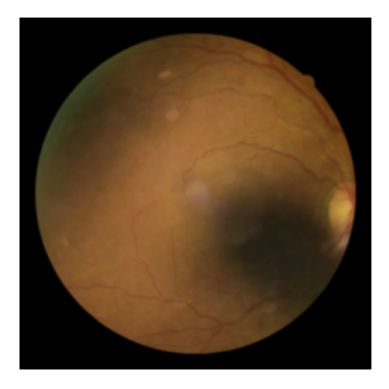

In [ ]:
from PIL import Image
image_path = '/content/image1.png'  # You can provide the path to an image file
image = Image.open(image_path)
plt.imshow(image)
plt.axis('off')  # Hide axes
plt.show()

In [ ]:
predict_diabetic_retinopathy(image)

ValueError: Exception encountered when calling Sequential.call().

[1mInvalid input shape for input Tensor("sequential_1/Cast:0", shape=(32, 224), dtype=float32). Expected shape (None, 299, 299, 3), but input has incompatible shape (32, 224)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(32, 224), dtype=uint8)
  • training=False
  • mask=None

#Gradio Interface

In [ ]:
import gradio as gr

# Define Gradio interface
def create_gradio_interface():
    # Gradio interface: user uploads an image, and we return the prediction
    interface = gr.Interface(
        fn=predict_diabetic_retinopathy,          # The function to call when image is uploaded
        inputs=gr.inputs.Image(type="pil"),      # Image input (accepts .jpg, .png, etc.)
        outputs=gr.outputs.Textbox(),            # Output is the predicted class (text)
        live=True,                               # Whether to display results live as the user interacts
        title="Diabetic Retinopathy Detection",  # Title of the app
        description="Upload a fundus image to detect diabetic retinopathy severity."
    )
    return interface

# Create and launch the Gradio interface
gradio_app = create_gradio_interface()
gradio_app.launch()

#Phase 1 Inferencing Code (CNN Model)
#Phase 1 Inferencing COde (Vision Transformer)
#Phase 2 Inferencing Code (CNN Model)
#Phase 2 Inferencing COde (Vision Transformer)
# Gradio UI Code